<a href="https://colab.research.google.com/github/kjesinthuyaUCLL/kjesinthuya/blob/main/MBTI_Tracks_Autoencoder.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# 1: Mount Drive and Load Data
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

DATA_PATH = "/content/drive/My Drive/mbti_tune_data/data/pretrain"

df = pd.read_csv(f"{DATA_PATH}/spotify_tracks.csv")
print(f"Loaded {len(df)} songs")

Mounted at /content/drive
Loaded 114000 songs


In [ ]:
# 2: Select Audio Features (matches your columns)
audio_features = ['danceability', 'energy', 'loudness', 'speechiness',
                  'acousticness', 'instrumentalness', 'liveness', 'valence',
                  'tempo', 'duration_ms', 'popularity', 'key', 'mode', 'time_signature']

# Check which features exist
available_features = [f for f in audio_features if f in df.columns]
print(f"Using {len(available_features)} features: {available_features}")

# Handle missing values
df[available_features] = df[available_features].fillna(df[available_features].median())

# Prepare X
X = df[available_features].values.astype(np.float32)
print(f"X shape: {X.shape}")

Using 14 features: ['danceability', 'energy', 'loudness', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'duration_ms', 'popularity', 'key', 'mode', 'time_signature']
X shape: (114000, 14)


In [ ]:
# 3: Normalize and Split
from sklearn.model_selection import train_test_split

X_train, X_val = train_test_split(X, test_size=0.1, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)

X_train = torch.tensor(X_train, dtype=torch.float32)
X_val = torch.tensor(X_val, dtype=torch.float32)

print(f"Train: {len(X_train):,}, Val: {len(X_val):,}")

# Save scaler
import pickle
with open(f"{DATA_PATH}/pretrain_scaler.pkl", 'wb') as f:
    pickle.dump(scaler, f)
print("✅ Saved pretrain_scaler.pkl")

Train: 102,600, Val: 11,400
✅ Saved pretrain_scaler.pkl


In [ ]:
# 4: Define Autoencoder (slightly larger for 114k data)
class Autoencoder(nn.Module):
    def __init__(self, input_dim, bottleneck_dim=16):
        super(Autoencoder, self).__init__()

        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, 32),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.Linear(32, bottleneck_dim)
        )

        self.decoder = nn.Sequential(
            nn.Linear(bottleneck_dim, 32),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.Linear(32, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Linear(64, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Linear(128, input_dim)
        )

    def forward(self, x):
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return encoded, decoded

    def encode(self, x):
        return self.encoder(x)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = Autoencoder(input_dim=len(available_features)).to(device)
print(f"Model has {sum(p.numel() for p in model.parameters()):,} parameters")
print(f"Using device: {device}")

Model has 26,462 parameters
Using device: cuda


Training Autoencoder on 114,000 songs...
--------------------------------------------------
Epoch  10/50 | Train Loss: 0.101522 | Val Loss: 0.042291
Epoch  20/50 | Train Loss: 0.084761 | Val Loss: 0.032130
Epoch  30/50 | Train Loss: 0.072743 | Val Loss: 0.027068
Epoch  40/50 | Train Loss: 0.063521 | Val Loss: 0.023353
Epoch  50/50 | Train Loss: 0.057597 | Val Loss: 0.019249


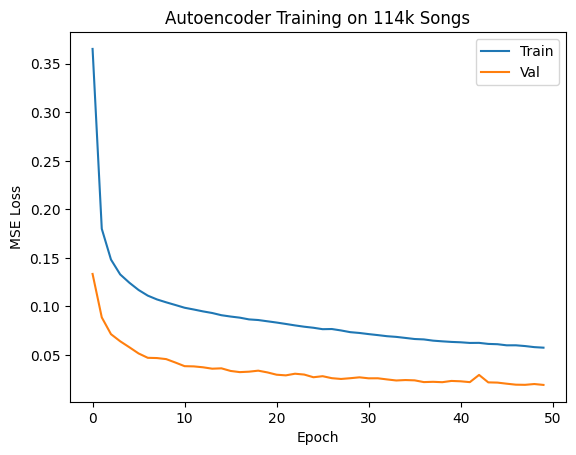

In [ ]:
# 5: Train Autoencoder
batch_size = 512
train_loader = DataLoader(TensorDataset(X_train), batch_size=batch_size, shuffle=True)
val_loader = DataLoader(TensorDataset(X_val), batch_size=batch_size)

criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-5)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=5, factor=0.5)

epochs = 50
train_losses = []
val_losses = []

print("Training Autoencoder on 114,000 songs...")
print("-" * 50)

for epoch in range(epochs):
    model.train()
    train_loss = 0
    for batch in train_loader:
        x = batch[0].to(device)
        _, reconstructed = model(x)
        loss = criterion(reconstructed, x)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        train_loss += loss.item()

    model.eval()
    val_loss = 0
    with torch.no_grad():
        for batch in val_loader:
            x = batch[0].to(device)
            _, reconstructed = model(x)
            val_loss += criterion(reconstructed, x).item()

    train_loss /= len(train_loader)
    val_loss /= len(val_loader)
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    scheduler.step(val_loss)

    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1:3d}/50 | Train Loss: {train_loss:.6f} | Val Loss: {val_loss:.6f}")

# Plot
plt.plot(train_losses, label='Train')
plt.plot(val_losses, label='Val')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('Autoencoder Training on 114k Songs')
plt.legend()
plt.show()

In [ ]:
# 6: Save Models
torch.save(model.state_dict(), f"{DATA_PATH}/autoencoder.pth")
torch.save(model.encoder.state_dict(), f"{DATA_PATH}/encoder.pth")
print("✅ Saved autoencoder.pth")
print("✅ Saved encoder.pth")

# Save feature list
import json
with open(f"{DATA_PATH}/pretrain_features.json", 'w') as f:
    json.dump(available_features, f, indent=2)
print("✅ Saved pretrain_features.json")

# Save final loss
final_loss = val_losses[-1]
print(f"\nFinal validation loss: {final_loss:.6f}")

✅ Saved autoencoder.pth
✅ Saved encoder.pth
✅ Saved pretrain_features.json

Final validation loss: 0.019249
